In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("netflix1.csv")
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [4]:
print("Initial dataset information:")


Initial dataset information:


In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB
None


In [6]:
print("\n Missing values Before Cleaning:")


 Missing values Before Cleaning:


In [7]:
print(data.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [8]:
#For removing the duplicate values
data.drop_duplicates(inplace=True)

In [10]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [11]:
data.size

87900

In [13]:
data.dtypes

show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object

In [14]:
#For checking the initial statistics
data.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
#for handling the missing values
missing_columns = [col for col in critical_columns if col not in data.columns]
if missing_columns:
    print("Missing columns: {missing_columns}")
else:
    data.dropna(subset=critical_columns, inplace=True)


Missing columns: ['cast']


In [19]:
data['date_added'] = pd.to_datetime(data['date_added'])


In [20]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


In [21]:
if 'duration' in data.columns and data['duration'].dtype != 'O':
    data = remove_outliers(data, 'duration')



In [22]:
print("\nDataset Info After Cleaning:")



Dataset Info After Cleaning:


In [23]:
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 686.8+ KB
None


In [24]:
print("\nMissing Values After Cleaning:")



Missing Values After Cleaning:


In [25]:
print(data.isnull().sum())


show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [29]:
data.to_csv("netflix_clean.csv", index=False)


In [30]:
print("Cleaned dataset saved as netflix_clean.csv")

Cleaned dataset saved as netflix_clean.csv


In [31]:
df = pd.read_csv('netflix_clean.csv')


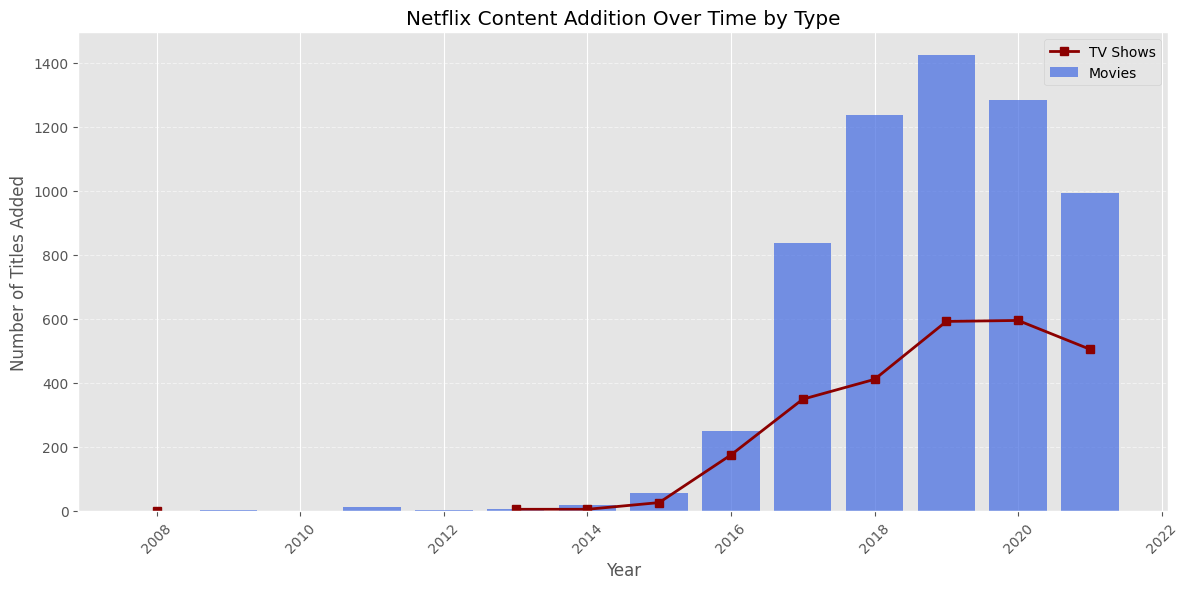

Yearly Content Addition Breakdown:
type         Movie  TV Show
date_added                 
2008           1.0      1.0
2009           2.0      NaN
2010           1.0      NaN
2011          13.0      NaN
2012           3.0      NaN
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         251.0    175.0
2017         836.0    349.0
2018        1237.0    411.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


In [37]:
# Convert date_added to datetime, handling missing values
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop rows where date_added is NaT (missing)
df = df.dropna(subset=['date_added'])

# Create yearly counts by type
yearly_counts = df.groupby([df['date_added'].dt.year, 'type']).size().unstack()

# Set an alternative style
plt.style.use('ggplot')

# Create figure with larger size
plt.figure(figsize=(12, 6))

# Plot bar graph for Movies
plt.bar(yearly_counts.index, yearly_counts['Movie'], color='royalblue', alpha=0.7, label='Movies')

# Plot line graph for TV Shows
plt.plot(yearly_counts.index, yearly_counts['TV Show'], marker='s', linestyle='-', linewidth=2, color='darkred', label='TV Shows')

plt.title('Netflix Content Addition Over Time by Type')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print the yearly counts
print("Yearly Content Addition Breakdown:")
print(yearly_counts)

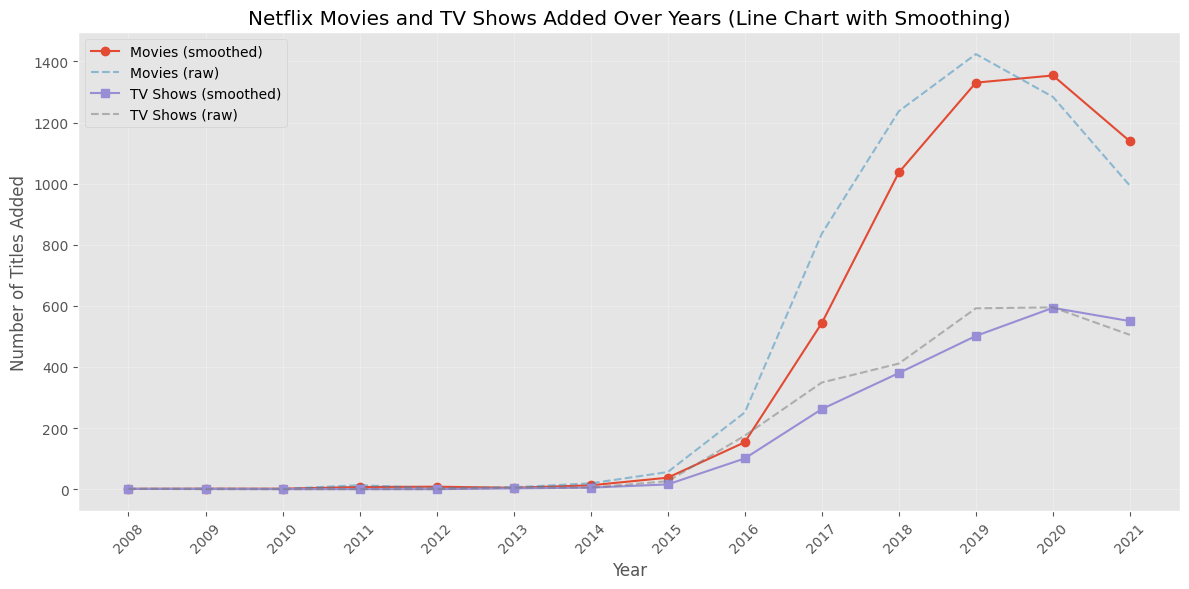

<Figure size 1200x600 with 0 Axes>

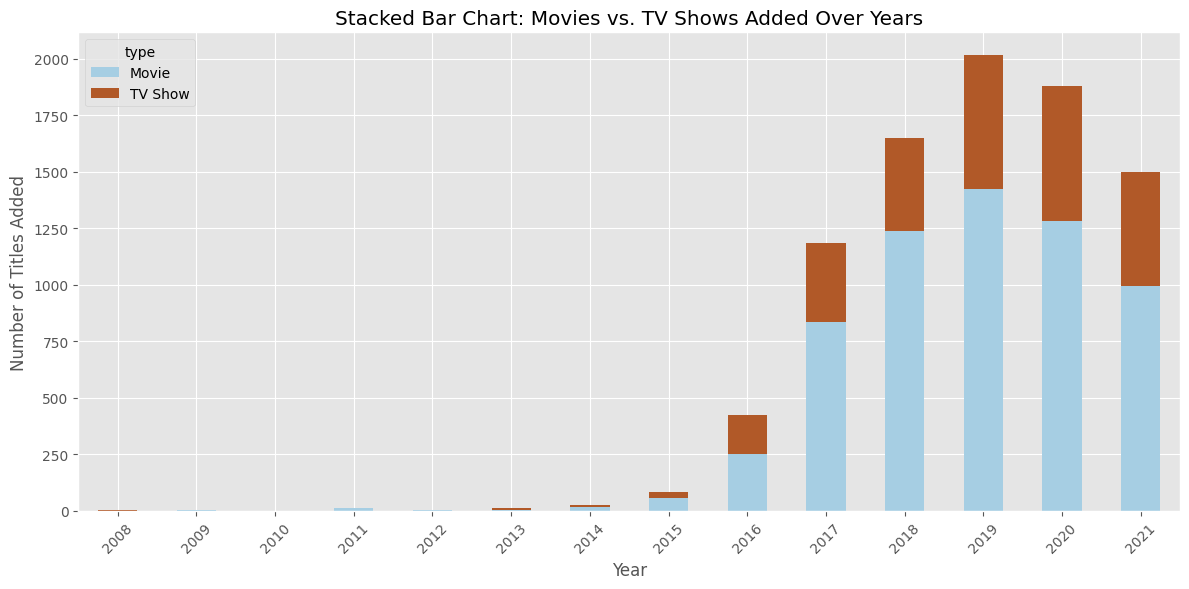

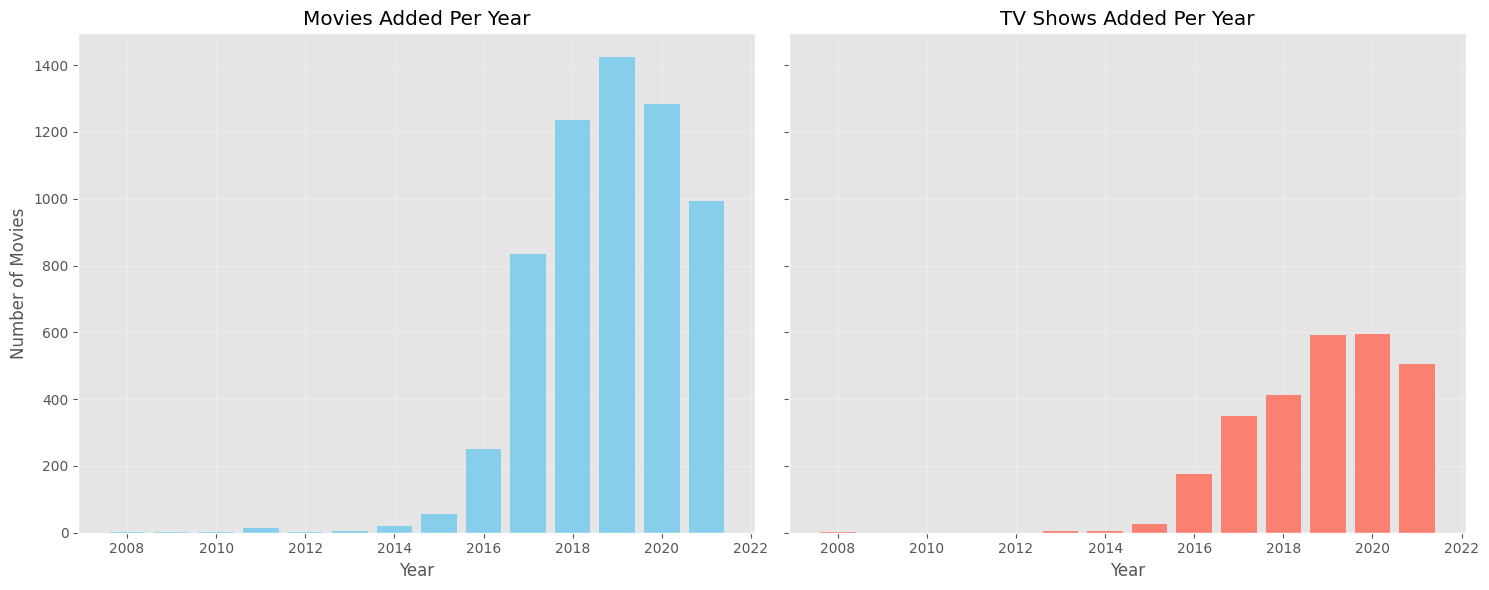

Generated three different charts: a line chart with smoothed trends, a stacked bar chart, and separate bar charts for Movies and TV Shows.


In [38]:
# Convert date_added to datetime if not already done
if df['date_added'].dtype != 'datetime64[ns]':
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year from date_added
df['year_added'] = df['date_added'].dt.year

# Group by year and type for counts
yearly_counts = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Sorted years
years = sorted(df['year_added'].dropna().unique())

# 1. Combined line chart with smoothing (rolling average)
plt.figure(figsize=(12,6))

# Movies and TV Shows lines
if 'Movie' in yearly_counts.columns:
    movies = yearly_counts['Movie']
    movies_smooth = movies.rolling(window=2, min_periods=1).mean()
    plt.plot(movies.index, movies_smooth, marker='o', label='Movies (smoothed)')
    plt.plot(movies.index, movies, linestyle='--', alpha=0.5, label='Movies (raw)')

if 'TV Show' in yearly_counts.columns:
    tv = yearly_counts['TV Show']
    tv_smooth = tv.rolling(window=2, min_periods=1).mean()
    plt.plot(tv.index, tv_smooth, marker='s', label='TV Shows (smoothed)')
    plt.plot(tv.index, tv, linestyle='--', alpha=0.5, label='TV Shows (raw)')

plt.title('Netflix Movies and TV Shows Added Over Years (Line Chart with Smoothing)')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(years, rotation=45)
plt.tight_layout()
plt.show()

# 2. Stacked Bar Chart
plt.figure(figsize=(12,6))

# Creating stacked bar chart for both type categories
yearly_counts.plot(kind='bar', stacked=True, colormap='Paired', figsize=(12,6))
plt.title('Stacked Bar Chart: Movies vs. TV Shows Added Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Separate Bar Charts for Movies and TV Shows highlighting spikes
fig, axes = plt.subplots(1,2, figsize=(15,6), sharey=True)

if 'Movie' in yearly_counts.columns:
    axes[0].bar(yearly_counts.index, yearly_counts['Movie'], color='skyblue')
    axes[0].set_title('Movies Added Per Year')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Number of Movies')
    axes[0].grid(True, alpha=0.3)

if 'TV Show' in yearly_counts.columns:
    axes[1].bar(yearly_counts.index, yearly_counts['TV Show'], color='salmon')
    axes[1].set_title('TV Shows Added Per Year')
    axes[1].set_xlabel('Year')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Generated three different charts: a line chart with smoothed trends, a stacked bar chart, and separate bar charts for Movies and TV Shows.')

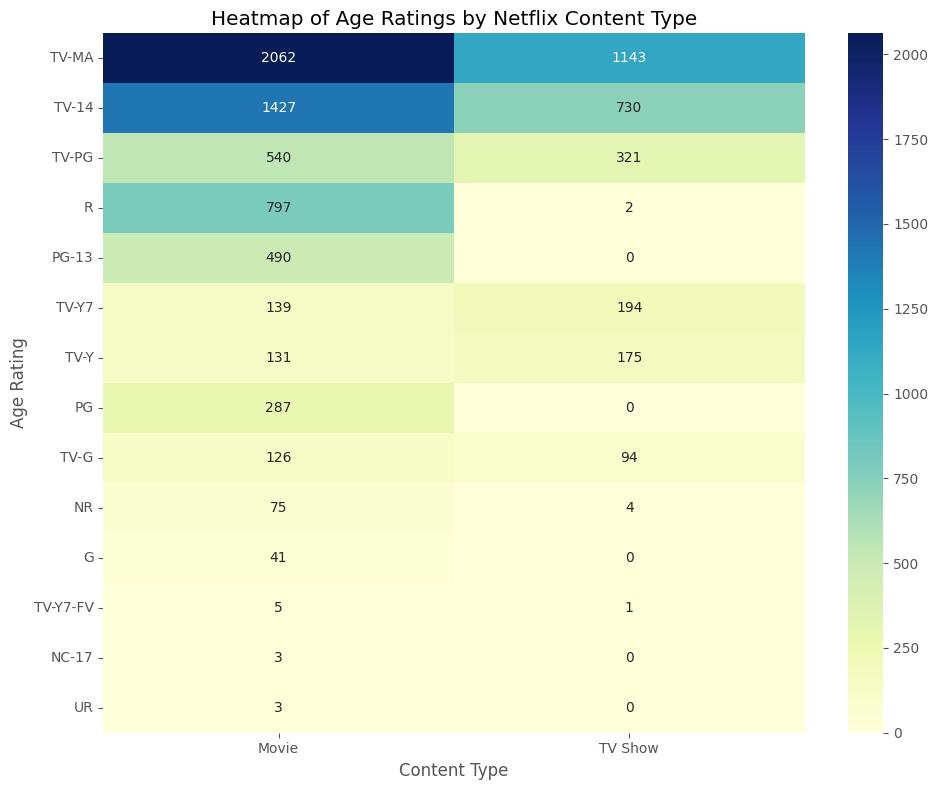

Generated heatmap for most common age ratings by Netflix Content Type.


In [39]:
# Create a pivot table: rows = rating, columns = type, values = count
age_rating_counts = df.groupby(['rating', 'type']).size().unstack(fill_value=0)

# Sort rows by total count descending for clearer visualization
age_rating_counts['total'] = age_rating_counts.sum(axis=1)
age_rating_counts = age_rating_counts.sort_values(by='total', ascending=False)
age_rating_counts = age_rating_counts.drop('total', axis=1)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(age_rating_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Age Ratings by Netflix Content Type')
plt.xlabel('Content Type')
plt.ylabel('Age Rating')
plt.tight_layout()
plt.show()

print('Generated heatmap for most common age ratings by Netflix Content Type.')

C:\Users\pruth\AppData\Local\Temp\ipykernel_32372\2297295075.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_countries.index, y=top10_countries.values, palette='viridis')


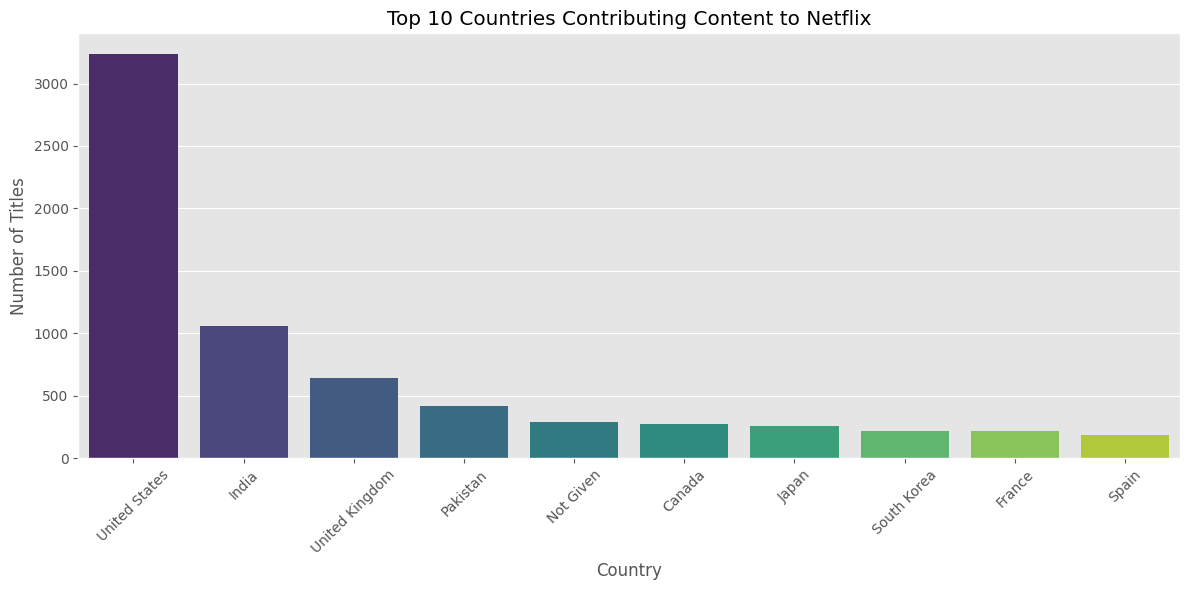

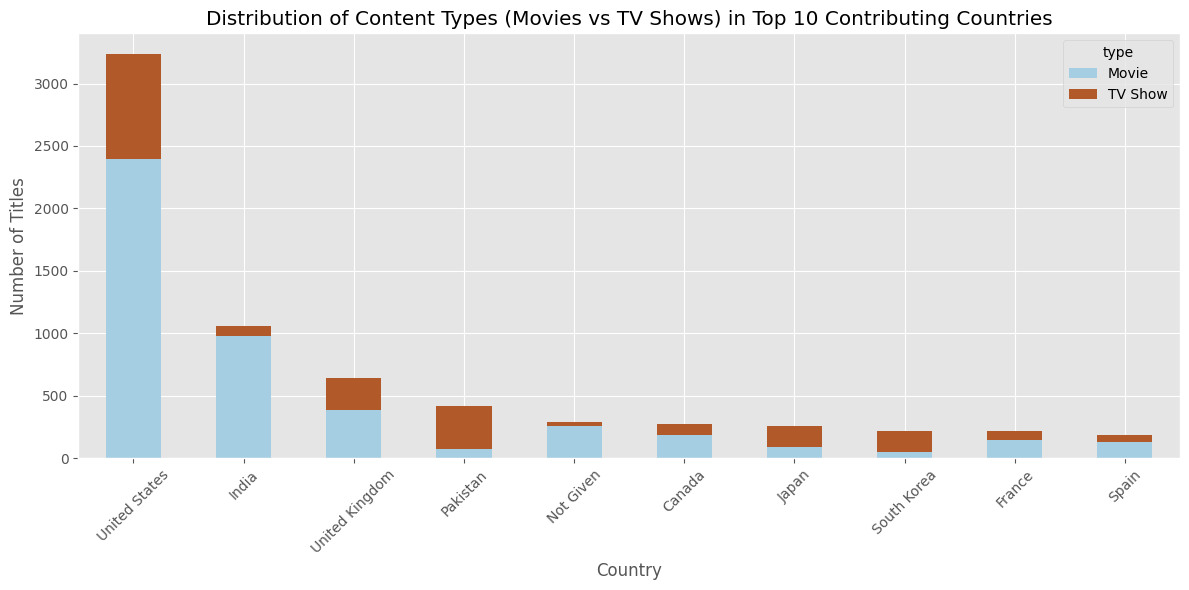

Generated bar charts for top contributing countries and the distribution of content types for these countries.


In [40]:
# Create a copy of df for processing countries
# Drop rows where country is NaN
df_country = df.dropna(subset=['country']).copy()

# Split the 'country' field by comma and explode into multiple rows
# Strip spaces during split
df_country['country'] = df_country['country'].apply(lambda x: [c.strip() for c in x.split(',')])
df_country_exploded = df_country.explode('country')

# Count the number of titles per country
country_counts = df_country_exploded['country'].value_counts()

# Get top 10 contributing countries
top10_countries = country_counts.head(10)

# Bar chart for top 10 contributing countries
plt.figure(figsize=(12,6))
sns.barplot(x=top10_countries.index, y=top10_countries.values, palette='viridis')
plt.title('Top 10 Countries Contributing Content to Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Now, for regional audience preferences, we can analyze the distribution of content types by country
# Let's get the counts of Movies vs TV Shows for top 10 countries to see impact

top10_list = list(top10_countries.index)
df_top10 = df_country_exploded[df_country_exploded['country'].isin(top10_list)]

# Group by country and type
country_type = df_top10.groupby(['country', 'type']).size().unstack(fill_value=0)

# Stacked bar chart for content type distribution in these top 10 countries
country_type = country_type.loc[top10_list]  # Ensure order is the same

country_type.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Paired')
plt.title('Distribution of Content Types (Movies vs TV Shows) in Top 10 Contributing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Generated bar charts for top contributing countries and the distribution of content types for these countries.')

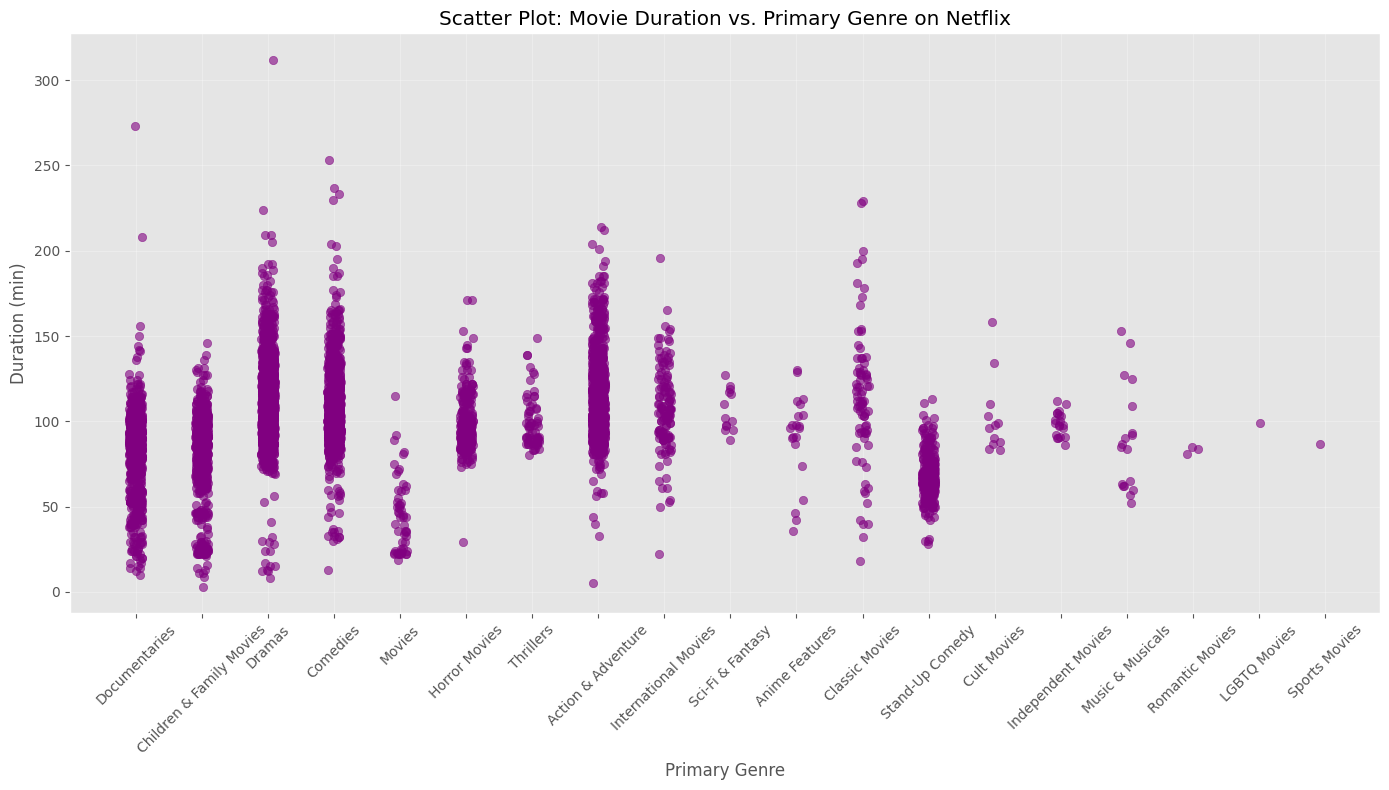

Average Duration per Genre (min):
primary_genre
Classic Movies          114.825000
Action & Adventure      113.515716
Dramas                  111.375235
International Movies    108.062500
Comedies                106.687603
Sci-Fi & Fantasy        106.615385
Cult Movies             102.500000
Thrillers                99.953846
LGBTQ Movies             99.000000
Independent Movies       98.700000
Name: duration_num, dtype: float64
Generated scatter plot of movie duration by primary genre.


In [41]:
# Filter for Movies only
movies_df = df[df['type'] == 'Movie'].copy()

# Remove rows with NaN in 'duration'
movies_df = movies_df.dropna(subset=['duration'])

# Convert duration to numeric: duration is in format 'XX min', so extract the number
movies_df['duration_num'] = movies_df['duration'].apply(lambda x: int(x.split()[0]) if isinstance(x, str) and x.split()[0].isdigit() else None)
movies_df = movies_df.dropna(subset=['duration_num'])

# Create a new column for primary genre (take the first genre from the 'listed_in' column; if missing, mark as 'Unknown')
def get_primary_genre(x):
    if isinstance(x, str):
        return x.split(',')[0].strip()
    else:
        return 'Unknown'

movies_df['primary_genre'] = movies_df['listed_in'].apply(get_primary_genre)

# Scatter plot: x-axis: primary genre (categorical), y-axis: duration, with jitter for clarity
plt.figure(figsize=(14,8))

# jitter x positions manually: map genres to numeric codes
unique_genres = movies_df['primary_genre'].unique()
genre_to_num = {genre: i for i, genre in enumerate(unique_genres)}

# Add jitter on x values
import numpy as np
jitter_strength = 0.1
x_values = movies_df['primary_genre'].map(genre_to_num) + np.random.uniform(-jitter_strength, jitter_strength, size=len(movies_df))
y_values = movies_df['duration_num']

plt.scatter(x_values, y_values, alpha=0.6, color='purple')

# Set x-ticks to the center of each genre
plt.xticks(ticks=list(genre_to_num.values()), labels=list(genre_to_num.keys()), rotation=45)
plt.xlabel('Primary Genre')
plt.ylabel('Duration (min)')
plt.title('Scatter Plot: Movie Duration vs. Primary Genre on Netflix')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also, calculate and print average duration per genre for summary
avg_duration = movies_df.groupby('primary_genre')['duration_num'].mean().sort_values(ascending=False)
print('Average Duration per Genre (min):')
print(avg_duration.head(10))

print('Generated scatter plot of movie duration by primary genre.')

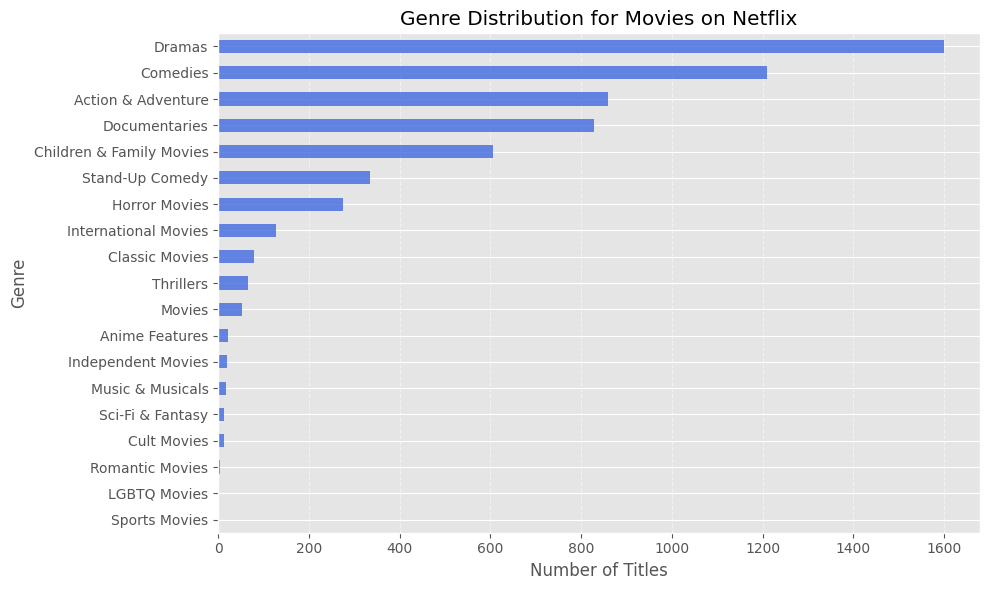

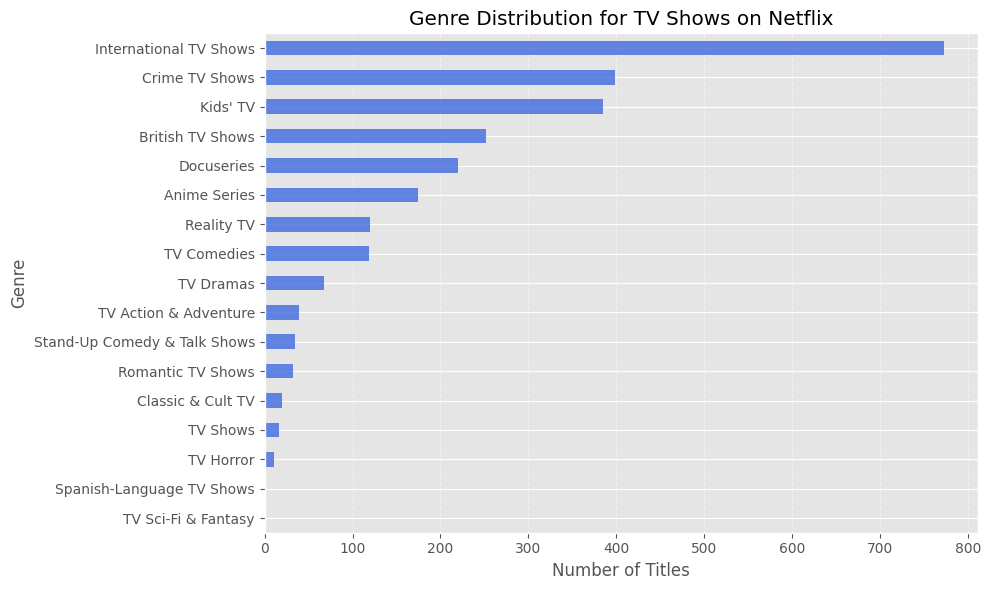

Generated horizontal bar charts for genre distribution by type (Movies vs. TV Shows).


In [44]:






# Function to extract primary genre
def extract_primary_genre(s):
    if isinstance(s, str):
        return s.split(',')[0].strip()
    return 'Unknown'

# Create a new column in df for primary genre
ds = df.copy()
ds['primary_genre'] = ds['listed_in'].apply(extract_primary_genre)

# Function to plot a horizontal bar chart
def plot_bar_chart(data, title):
    plt.figure(figsize=(10, 6))
    data.sort_values().plot(kind='barh', color='royalblue', alpha=0.8)
    
    plt.title(title)
    plt.xlabel('Number of Titles')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# For Movies
movies = ds[ds['type'] == 'Movie']
movie_genre_counts = movies['primary_genre'].value_counts()
plot_bar_chart(movie_genre_counts, 'Genre Distribution for Movies on Netflix')

# For TV Shows
tv_shows = ds[ds['type'] == 'TV Show']
tv_genre_counts = tv_shows['primary_genre'].value_counts()
plot_bar_chart(tv_genre_counts, 'Genre Distribution for TV Shows on Netflix')

print('Generated horizontal bar charts for genre distribution by type (Movies vs. TV Shows).')


